<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_NBEATS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install

# Install

In [ ]:
!pip -q install -U Kaggle neuralforecast mlflow dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 23.6 MB/s eta 0:00:00


# Imports + Config

In [ ]:
import os
import random
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = False
VALIDATION_WEEKS = 13
INPUT_SIZE = 52
FREQ = "W-FRI"

PROJECT_NAME = "walmart-store-sales-forecasting"
MODEL_NAME = "NBEATS"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Paths + Kaggle Credentials

In [ ]:
import os
from pathlib import Path
from google.colab import drive, userdata

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/walmart_final_project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / MODEL_NAME.lower()

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_token = userdata.get("KAGGLE_API_TOKEN")

if kaggle_username is None or kaggle_token is None:
    raise ValueError("Colab Secrets-ში KAGGLE_USERNAME ან KAGGLE_API_TOKEN არ ჩანს.")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_token

print("DATA_DIR:", DATA_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("Kaggle credentials loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/walmart_final_project/data
ARTIFACT_DIR: /content/drive/MyDrive/walmart_final_project/artifacts/nbeats
Kaggle credentials loaded.


# Download Competition Data

In [ ]:
competition_name = "walmart-recruiting-store-sales-forecasting"
zip_path = DATA_DIR / f"{competition_name}.zip"

if not zip_path.exists():
    !kaggle competitions download -c {competition_name} -p {DATA_DIR}
else:
    print("Competition zip already exists:", zip_path)

!unzip -o {zip_path} -d {DATA_DIR}

Competition zip already exists: /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
Archive:  /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
  inflating: /content/drive/MyDrive/walmart_final_project/data/features.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/sampleSubmission.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/stores.csv  
  inflating: /content/drive/MyDrive/walmart_final_project/data/test.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/train.csv.zip  


# Load Data

In [ ]:
train = pd.read_csv(DATA_DIR / "train.csv.zip")
test = pd.read_csv(DATA_DIR / "test.csv.zip")
features = pd.read_csv(DATA_DIR / "features.csv.zip")
stores = pd.read_csv(DATA_DIR / "stores.csv")
sample_submission = pd.read_csv(DATA_DIR / "sampleSubmission.csv.zip")

for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Metric

In [ ]:
def walmart_wmae(y_true, y_pred, is_holiday):
    weights = np.where(pd.Series(is_holiday).astype(bool).to_numpy(), 5, 1)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.sum(weights * errors) / np.sum(weights))

# Preprocessing Functions

In [ ]:
def make_unique_id(df):
    return df["Store"].astype(str) + "_" + df["Dept"].astype(str)


def build_calendar(train_df, test_df):
    calendar = pd.concat(
        [
            train_df[["Date", "IsHoliday"]],
            test_df[["Date", "IsHoliday"]],
        ],
        ignore_index=True,
    )

    calendar = (
        calendar
        .drop_duplicates("Date")
        .rename(columns={"Date": "ds"})
        .sort_values("ds")
        .reset_index(drop=True)
    )

    return calendar


def prepare_nbeats_frame(raw_train, calendar):
    base = raw_train.copy()
    base["unique_id"] = make_unique_id(base)

    base = base.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    base = base[["unique_id", "ds", "y"]]

    all_ids = base["unique_id"].drop_duplicates().sort_values()
    all_dates = pd.date_range(base["ds"].min(), base["ds"].max(), freq=FREQ)

    full_grid = (
        pd.MultiIndex
        .from_product([all_ids, all_dates], names=["unique_id", "ds"])
        .to_frame(index=False)
    )

    out = full_grid.merge(base, on=["unique_id", "ds"], how="left")
    out["y"] = out["y"].fillna(0.0)

    out = out.merge(calendar, on="ds", how="left")
    out["IsHoliday"] = out["IsHoliday"].fillna(False).astype(bool)

    return out.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Build N-BEATS Dataset

In [ ]:
calendar = build_calendar(train, test)
nf_full = prepare_nbeats_frame(train, calendar)

if QUICK_RUN:
    top_ids = (
        train.assign(unique_id=make_unique_id(train))
        .groupby("unique_id")["Weekly_Sales"]
        .sum()
        .nlargest(120)
        .index
    )

    nf_full = nf_full[nf_full["unique_id"].isin(top_ids)].copy()

print("series:", nf_full["unique_id"].nunique())
print("date range:", nf_full["ds"].min().date(), "to", nf_full["ds"].max().date())
print("rows:", len(nf_full))

nf_full.head()

series: 3331
date range: 2010-02-05 to 2012-10-26
rows: 476333


,unique_id,ds,y,IsHoliday
0,10_1,2010-02-05,40212.84,False
1,10_1,2010-02-12,67699.32,True
2,10_1,2010-02-19,49748.33,False
3,10_1,2010-02-26,33601.22,False
4,10_1,2010-03-05,36572.44,False


# MLflow + DagsHub

In [ ]:
from google.colab import userdata

DAGSHUB_USERNAME = "mgior23"      # შენი user
DAGSHUB_REPO_OWNER = "adzid23"    # repo-ს owner
DAGSHUB_REPO_NAME = "Freeuni_ML_Walmart_Sales_Forecasting"

dagshub_token = userdata.get("DAGSHUB_TOKEN")

if dagshub_token is None:
    raise ValueError("Colab Secrets-ში DAGSHUB_TOKEN არ ჩანს.")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
)

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("NBEATS_Training")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow username:", DAGSHUB_USERNAME)
print("Repo owner:", DAGSHUB_REPO_OWNER)
print("Experiment: NBEATS_Training")

MLflow tracking URI: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow
MLflow username: mgior23
Repo owner: adzid23
Experiment: NBEATS_Training


# Log Preprocessing Run

In [ ]:
with mlflow.start_run(run_name="NBEATS_Preprocessing"):
    mlflow.log_params({
        "model_family": "Deep Learning",
        "architecture": "N-BEATS",
        "frequency": FREQ,
        "missing_week_strategy": "fill_missing_sales_with_zero",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
    })

    mlflow.log_metrics({
        "n_series": nf_full["unique_id"].nunique(),
        "n_rows": len(nf_full),
        "n_dates": nf_full["ds"].nunique(),
    })

print("Preprocessing run logged.")

🏃 View run NBEATS_Preprocessing at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2/runs/814e81d343fa4f7fab2a583e9a140c1a
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2
Preprocessing run logged.


# Validation Split

In [ ]:
last_train_date = nf_full["ds"].max()
valid_start = last_train_date - pd.Timedelta(weeks=VALIDATION_WEEKS - 1)

train_part = nf_full[nf_full["ds"] < valid_start][["unique_id", "ds", "y"]].copy()
valid_part = nf_full[nf_full["ds"] >= valid_start].copy()

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("validation start:", valid_start.date())

train_part: (433030, 3)
valid_part: (43303, 4)
validation start: 2012-08-03


# Train Baseline N-BEATS

In [ ]:
MAX_STEPS = 50 if QUICK_RUN else 1500

nbeats = NBEATS(
    h=VALIDATION_WEEKS,
    input_size=INPUT_SIZE,
    max_steps=MAX_STEPS,
    scaler_type="robust",
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

forecast_engine = NeuralForecast(models=[nbeats], freq=FREQ)

with mlflow.start_run(run_name="NBEATS_Training_Baseline") as run:
    mlflow.log_params({
        "architecture": "N-BEATS",
        "run_type": "baseline",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": INPUT_SIZE,
        "max_steps": MAX_STEPS,
        "scaler_type": "robust",
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    forecast_engine.fit(df=train_part)
    pred = forecast_engine.predict()

    scored = valid_part.merge(pred, on=["unique_id", "ds"], how="inner")
    scored["NBEATS"] = scored["NBEATS"].clip(lower=0)

    validation_wmae = walmart_wmae(
        scored["y"],
        scored["NBEATS"],
        scored["IsHoliday"]
    )

    mlflow.log_metric("validation_wmae", validation_wmae)

    save_path = ARTIFACT_DIR / "baseline_model"
    forecast_engine.save(
        path=str(save_path),
        model_index=None,
        overwrite=True,
        save_dataset=False
    )

    mlflow.log_artifacts(str(save_path), artifact_path="model")

    scored_path = ARTIFACT_DIR / "baseline_validation_predictions.csv"
    scored.to_csv(scored_path, index=False)
    mlflow.log_artifact(str(scored_path), artifact_path="validation")

    baseline_run_id = run.info.run_id

print("Validation WMAE:", round(validation_wmae, 4))
print("Run ID:", baseline_run_id)

scored.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.5 M  | train
--------------------------------------------------------------
2.5 M     Trainable params
1.8 K     Non-trainable params
2.5 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Training_Baseline at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2/runs/20e64f613f7946d58059961680307a79
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2
Validation WMAE: 1798.8131
Run ID: 20e64f613f7946d58059961680307a79


,unique_id,ds,y,IsHoliday,NBEATS
0,10_1,2012-08-03,26390.26,False,33468.453125
1,10_1,2012-08-10,26320.29,False,19780.589844
2,10_1,2012-08-17,26752.40,False,26527.308594
3,10_1,2012-08-24,26804.84,False,27846.097656
4,10_1,2012-08-31,26083.28,False,29034.091797


# Visual Inspection

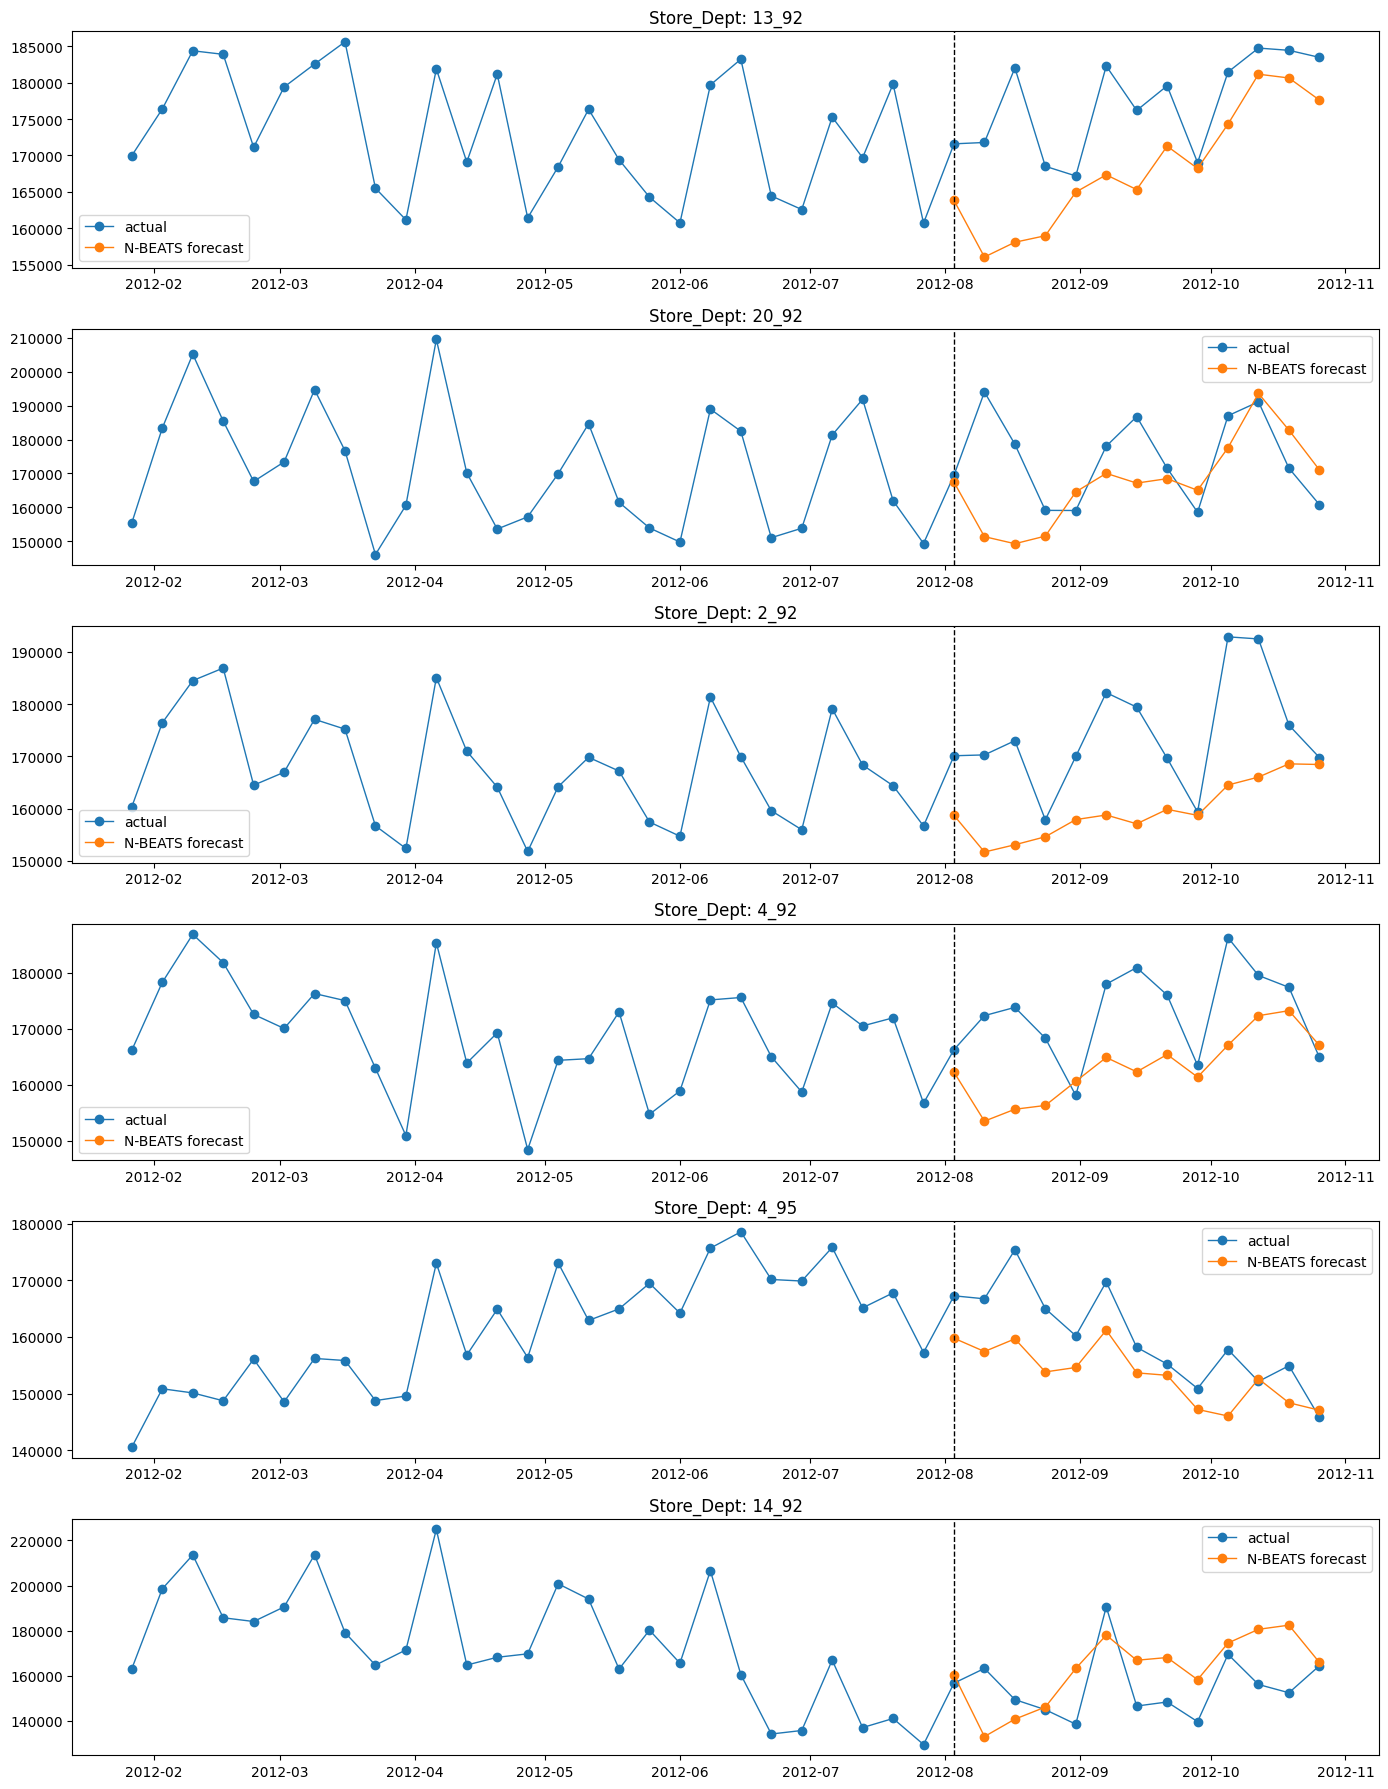

🏃 View run NBEATS_Validation_Visualization at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2/runs/eb77021ddcc540569ead5aaf452bad79
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2
Validation plot logged.


In [ ]:
plot_ids = scored.groupby("unique_id")["y"].sum().nlargest(6).index

fig, axes = plt.subplots(len(plot_ids), 1, figsize=(14, 3 * len(plot_ids)), sharex=False)

if len(plot_ids) == 1:
    axes = [axes]

for ax, uid in zip(axes, plot_ids):
    hist = nf_full[nf_full["unique_id"] == uid].tail(40)
    val = scored[scored["unique_id"] == uid]

    ax.plot(hist["ds"], hist["y"], label="actual", marker="o", linewidth=1)
    ax.plot(val["ds"], val["NBEATS"], label="N-BEATS forecast", marker="o", linewidth=1)
    ax.axvline(valid_start, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Store_Dept: {uid}")
    ax.legend()

plt.tight_layout()

plot_path = ARTIFACT_DIR / "baseline_validation_plot.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_name="NBEATS_Validation_Visualization"):
    mlflow.log_param("source_run_id", baseline_run_id)
    mlflow.log_artifact(str(plot_path), artifact_path="plots")

print("Validation plot logged.")

# Small Tuning Run

In [ ]:
second_input_size = 78
second_steps = 80 if QUICK_RUN else 2000

model_2 = NBEATS(
    h=VALIDATION_WEEKS,
    input_size=second_input_size,
    max_steps=second_steps,
    scaler_type="standard",
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

nf_2 = NeuralForecast(models=[model_2], freq=FREQ)

with mlflow.start_run(run_name="NBEATS_Tuning_Input78_StandardScaler") as run:
    mlflow.log_params({
        "architecture": "N-BEATS",
        "run_type": "hyperparameter_tuning",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": second_input_size,
        "max_steps": second_steps,
        "scaler_type": "standard",
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    nf_2.fit(df=train_part)
    pred_2 = nf_2.predict()

    scored_2 = valid_part.merge(pred_2, on=["unique_id", "ds"], how="inner")
    scored_2["NBEATS"] = scored_2["NBEATS"].clip(lower=0)

    score_2 = walmart_wmae(
        scored_2["y"],
        scored_2["NBEATS"],
        scored_2["IsHoliday"]
    )

    mlflow.log_metric("validation_wmae", score_2)

    save_path_2 = ARTIFACT_DIR / "input78_standard_model"
    nf_2.save(
        path=str(save_path_2),
        model_index=None,
        overwrite=True,
        save_dataset=False
    )

    mlflow.log_artifacts(str(save_path_2), artifact_path="model")

    scored_2_path = ARTIFACT_DIR / "input78_standard_validation_predictions.csv"
    scored_2.to_csv(scored_2_path, index=False)
    mlflow.log_artifact(str(scored_2_path), artifact_path="validation")

    tuning_run_id = run.info.run_id

print("Second config WMAE:", round(score_2, 4))
print("Run ID:", tuning_run_id)

scored_2.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.6 M  | train
--------------------------------------------------------------
2.6 M     Trainable params
2.5 K     Non-trainable params
2.6 M     T

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run NBEATS_Tuning_Input78_StandardScaler at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2/runs/c62cbbe98f2c4a6ba9d7b8715a324be0
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/2
Second config WMAE: 1179.6008
Run ID: c62cbbe98f2c4a6ba9d7b8715a324be0


,unique_id,ds,y,IsHoliday,NBEATS
0,10_1,2012-08-03,26390.26,False,24772.203125
1,10_1,2012-08-10,26320.29,False,28888.277344
2,10_1,2012-08-17,26752.40,False,24384.585938
3,10_1,2012-08-24,26804.84,False,24612.343750
4,10_1,2012-08-31,26083.28,False,23011.919922


# Comparison

In [ ]:
runs = mlflow.search_runs(experiment_names=["NBEATS_Training"])

cols = [
    "tags.mlflow.runName",
    "metrics.validation_wmae",
    "params.run_type",
    "params.input_size",
    "params.max_steps",
    "params.scaler_type",
    "params.quick_run",
]

available_cols = [col for col in cols if col in runs.columns]

comparison = (
    runs[available_cols]
    .dropna(subset=["metrics.validation_wmae"])
    .sort_values("metrics.validation_wmae")
)

comparison

,tags.mlflow.runName,metrics.validation_wmae,params.run_type,params.input_size,params.max_steps,params.scaler_type,params.quick_run
0,NBEATS_Tuning_Input78_StandardScaler,1179.600769,hyperparameter_tuning,78,2000,standard,False
2,NBEATS_Training_Baseline,1798.813125,baseline,52,1500,robust,False
6,NBEATS_Training_Baseline,5010.357141,baseline,52,50,robust,True
4,NBEATS_Tuning_Input78_StandardScaler,5903.816110,hyperparameter_tuning,78,80,standard,True
